In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cpa

from tqdm import tqdm

from utils import set_seed

Global seed set to 0


In [4]:
set_seed(0)

In [5]:
batch_size = 4096

## Load data

In [142]:
adata = sc.read(
    "/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url="https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

In [143]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

## Data splits

In [144]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_celltype = ["Fibroblast"]
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    #is_holdout_ct = adata.obs["coarse_type"].isin(holdout_celltype)
    is_holdout_ct = adata.obs['coarse_type']!="Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [145]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [146]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [147]:
adata.obs['data_split'] = 'train'
adata.obs.iloc[val_idx, adata.obs.columns.get_loc('data_split')] = 'valid'
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('data_split')] = 'ood'

## Model selection

In [148]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [149]:
model_class = 'cpa'

In [150]:
adata.X = adata.layers['counts'].copy()

In [151]:
adata.obs['dose'] = 1.0 # NOTE: dummy dose for compatibility with CPA model

# Set perturbation column to 'perturbed' for cells in CRC region, REF and TVA are controls
adata.obs['perturbation'] = 'ctrl'
mask = np.zeros(adata.n_obs, dtype=bool)
mask[is_tumor_region] = True
adata.obs.loc[mask, "perturbation"] = 'perturbed'

In [152]:
cpa.CPA.setup_anndata(adata,
                      perturbation_key='perturbation',
                      control_group='ctrl',
                      dosage_key='dose',
                      categorical_covariate_keys=[labels_key],
                      is_count_data=True,
                      max_comb_len=1,
                     )

100%|██████████| 420694/420694 [00:00<00:00, 1459741.93it/s]


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [153]:
model_params = {
    "n_latent": 64,
    "recon_loss": "nb",
    "doser_type": "linear",
    "n_hidden_encoder": 128,
    "n_layers_encoder": 2,
    "n_hidden_decoder": 512,
    "n_layers_decoder": 2,
    "use_batch_norm_encoder": True,
    "use_layer_norm_encoder": False,
    "use_batch_norm_decoder": False,
    "use_layer_norm_decoder": True,
    "dropout_rate_encoder": 0.0,
    "dropout_rate_decoder": 0.1,
    "variational": False,
    "seed": 6977,
}

trainer_params = {
    "n_epochs_kl_warmup": None,
    "n_epochs_pretrain_ae": 30,
    "n_epochs_adv_warmup": 50,
    "n_epochs_mixup_warmup": 0,
    "mixup_alpha": 0.0,
    "adv_steps": None,
    "n_hidden_adv": 64,
    "n_layers_adv": 3,
    "use_batch_norm_adv": True,
    "use_layer_norm_adv": False,
    "dropout_rate_adv": 0.3,
    "reg_adv": 20.0,
    "pen_adv": 5.0,
    "lr": 0.0003,
    "wd": 4e-07,
    "adv_lr": 0.0003,
    "adv_wd": 4e-07,
    "adv_loss": "cce",
    "doser_lr": 0.0003,
    "doser_wd": 4e-07,
    "do_clip_grad": True,
    "gradient_clip_value": 1.0,
    "step_size_lr": 10,
}

In [154]:
model = cpa.CPA(adata=adata,
                split_key='data_split',
                train_split='train',
                valid_split='valid',
                test_split='ood',
                **model_params,
               )

Global seed set to 6977


In [155]:
save_path = f'{base_path}/cpa/lightning_logs/Kang/'
#save_path = f'{base_path}/cpa/lightning_logs/CRC_no_covariates/'
#save_path = f'{base_path}/cpa/lightning_logs/CRC_Fibroblast/'

In [53]:
model.train(max_epochs=100,
            use_gpu=True,
            batch_size=batch_size,
            plan_kwargs=trainer_params,
            early_stopping_patience=5,
            check_val_every_n_epoch=5,
            save_path=save_path,
           )

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  7.80it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 5/100:   4%|▍         | 4/100 [01:25<34:52, 21.80s/it, v_num=1, recon=432, r2_mean=0.745, adv_loss=0.157, acc_pert=0.927]


Epoch 00004: cpa_metric reached. Module best state updated.


Epoch 10/100:   9%|▉         | 9/100 [03:33<38:25, 25.33s/it, v_num=1, recon=421, r2_mean=0.765, adv_loss=0.09, acc_pert=0.961, val_recon=431, disnt_basal=0.736, disnt_after=1, val_r2_mean=0.729, val_KL=nan] 

...


disnt_basal = 0.5637038745436749
disnt_after = 1.0
val_r2_mean = 0.7765603138340845
val_r2_var = 0.679178241888682
Epoch 60/100:  59%|█████▉    | 59/100 [22:22<13:36, 19.91s/it, v_num=1, recon=401, r2_mean=0.792, adv_loss=0.612, acc_pert=0.512, val_recon=406, disnt_basal=0.575, disnt_after=1, val_r2_mean=0.771, val_KL=nan]


Epoch 00059: cpa_metric reached. Module best state updated.



disnt_basal = 0.5540625384892921
disnt_after = 1.0
val_r2_mean = 0.7754553741878933
val_r2_var = 0.6846864150630104
Epoch 65/100:  64%|██████▍   | 64/100 [24:06<12:05, 20.14s/it, v_num=1, recon=400, r2_mean=0.792, adv_loss=0.615, acc_pert=0.506, val_recon=405, disnt_basal=0.554, disnt_after=1, val_r2_mean=0.775, val_KL=nan]


Epoch 00064: cpa_metric reached. Module best state updated.


Epoch 70/100:  69%|██████▉   | 69/100 [25:51<10:25, 20.18s/it, v_num=1, recon=399, r2_mean=0.794, adv_loss=0.619, acc_pert=0.501, val_recon=404, disnt_basal=0.536, disnt_after=1, val_r2_mean=0.795, val_KL=nan]
disnt_basal = 0.5933104188226234
disnt_after = 1.0
val_r2_mean = 0.7926778415838877
val_r2_var = 0.6934951431221431
Epoch 80/100:  79%|███████▉  | 79/100 [29:24<07:03, 20.14s/it, v_num=1, recon=398, r2_mean=0.796, adv_loss=0.616, acc_pert=0.5, val_recon=404, disnt_basal=0.569, disnt_after=1, val_r2_mean=0.784, val_KL=nan]  
disnt_basal = 0.5665834039457572
disnt_after = 1.0
val_r2_mean = 0.7899165570735931
val_r2_var = 0.6960586541228824
Epoch 90/100:  89%|████████▉ | 89/100 [32:52<03:44, 20.41s/it, v_num=1, recon=397, r2_mean=0.799, adv_loss=0.616, acc_pert=0.5, val_recon=402, disnt_basal=0.547, disnt_after=1, val_r2_mean=0.793, val_KL=nan]
disnt_basal = 0.6232210336135917
disnt_after = 1.0
val_r2_mean = 0.791094454129537
val_r2_var = 0.696693401866489
Epoch 90/100:  90%|███████

## Analysis

In [156]:
model = cpa.CPA.load(dir_path=save_path,
                     adata=adata,
                     use_gpu=True)

INFO     File /data2/a330d/data/cellina-reproducibility/cpa/lightning_logs/Kang/model.pt already downloaded        


100%|██████████| 420694/420694 [00:00<00:00, 1582394.42it/s]
Global seed set to 6977


In [26]:
adata.obs.columns

Index(['fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px',
       'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18',
       'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45',
       'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash',
       'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name',
       'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID',
       'CenterX_global_px', 'CenterY_global_px', 'cell_ID',
       'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75',
       'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9',
       'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA',
       'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8',
       'negprobes_quantile_0.85', 'negprobes_quantile_0.9',
       'negprobes_quantile_0.95', 'negprobes_quantile_0.99',
       'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode',
       'falsecode_quantile_0.75', 

In [157]:
model.get_pert_embeddings().X[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [158]:
model.get_pert_embeddings().obs

,pert_name
0,<PAD>
1,ctrl
2,perturbed


In [159]:
model.get_pert_embeddings().X[1]

array([ 0.32552192,  0.9088712 ,  0.5010219 ,  0.0101601 ,  0.30751014,
       -0.80440336, -3.2469156 ,  1.329216  , -1.4480162 , -1.9841626 ,
       -0.2904156 ,  2.0447428 , -0.88047075, -0.59437525, -0.45168528,
        0.48545614,  0.8347467 ,  1.7664299 , -0.93031186,  0.90299827,
        0.56966203, -1.0934385 , -0.12002425, -1.1628956 , -1.3119032 ,
       -0.53592   ,  0.31117424,  0.16300735,  0.8131293 , -0.06782188,
       -0.08097179,  0.49694744,  2.0924351 , -0.62353855,  1.2620677 ,
       -0.48793977,  0.42430308, -0.7990988 ,  0.8336316 , -0.26332873,
        0.08242482,  0.37856492, -0.50794995, -0.40389994,  1.6402429 ,
       -0.8799809 , -0.3567137 ,  0.67541367, -2.7166586 ,  0.47319734,
        0.745284  ,  0.7479809 , -1.2004675 , -0.14011015, -0.6449429 ,
        0.29649177, -1.8114481 , -0.85876435, -2.089519  ,  1.7174488 ,
        1.397771  ,  0.10641505,  0.83588445,  0.44064677], dtype=float32)

In [160]:
model.get_pert_embeddings().X[2]

array([-0.31157735, -0.5705512 , -0.15200427,  0.00924283, -0.5477452 ,
       -1.3570646 , -0.8965225 ,  0.04592712, -0.76147616, -0.7111811 ,
       -0.35302168,  0.25779822, -1.3416284 , -1.9605327 , -0.4260212 ,
        0.4306426 ,  0.81371486, -0.09297781, -0.39466923,  1.1391283 ,
       -0.96066815,  0.74860674,  0.27242085, -0.04248311, -1.5729336 ,
        0.22238867, -0.04627039,  0.37771744,  0.01031419,  1.3417667 ,
        0.8636437 , -1.0858405 , -1.0491621 ,  0.34403223,  0.09648005,
        0.78446317,  0.02191959, -1.2214255 ,  1.271643  , -2.3532302 ,
       -0.26102665, -2.19557   ,  1.4382281 , -0.3754441 ,  0.15269616,
        0.03663196,  1.286585  ,  0.5970639 , -1.2951411 , -1.6851557 ,
       -0.12399332,  1.0506394 ,  0.18989794,  0.02472665,  1.4161581 ,
        0.2997042 , -0.1748451 ,  0.3981502 , -1.9258351 , -0.11048217,
       -0.01335052, -0.75112075,  1.1794575 , -1.3926173 ], dtype=float32)

In [94]:
results = {}
for celltype in tqdm(adata[adata.obs["is_holdout"]].obs[labels_key].cat.categories):
    mask_control = (~adata.obs["is_holdout"]) & (adata.obs[labels_key] == celltype)
    idx_control = np.where(mask_control.values)[0]
    adata_control = adata[mask_control].copy()

    #mask_target = (adata.obs["is_holdout"]) & (adata.obs[labels_key] == celltype)
    #idx_target = np.where(mask_target.values)[0]
    #adata_target = adata[mask_target].copy()

    adata_cf = adata[mask_control].copy()  # CPA and scvi don't use spatial info, so just copy control as placeholder

    # Save original expression (CPA expects this)
    adata_cf.obsm["X_true"] = adata_control.X.copy()

    # Now flip perturbation
    adata_cf.obs["perturbation"] = "perturbed"

    #cols = adata[adata.obs['CPA_cat']=='Fibroblast_perturbed'].obs.columns[-6:]
    #vals = adata[adata.obs['CPA_cat']=='Fibroblast_perturbed'].obs.loc[adata[adata.obs['CPA_cat']=='Fibroblast_perturbed'].obs.index[0], cols]
    #adata_cf.obs.loc[:, cols] = vals.values

    # Predict control
    model.predict(adata_control) 
    model.predict(adata_cf)

    latents_control = model.get_latent_representation(adata=adata_control)
    adata_control.obsm[f"{model_class}_latent_basal"] = latents_control if model_class != 'cpa' else latents_control['latent_basal'].X
    adata_control.obsm[f"{model_class}_latent_after"] = latents_control if model_class != 'cpa' else latents_control['latent_after'].X

    latents_cf = model.get_latent_representation(adata=adata_cf)
    adata_cf.obsm[f"{model_class}_latent_basal"] = latents_cf if model_class != 'cpa' else latents_cf['latent_basal'].X
    adata_cf.obsm[f"{model_class}_latent_after"] = latents_cf if model_class != 'cpa' else latents_cf['latent_after'].X

  0%|          | 0/1 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 684/684 [00:04<00:00, 170.40it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 1/1 [00:14<00:00, 14.34s/it]


In [75]:
adata_control.obs

,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68_CK8_18,...,n_counts,is_holdout,data_split,dose,perturbation,CPA_cat,CPA_ctrl,_scvi_perturbation,_scvi_coarse_type,_scvi_CPA_cat
c_4_63_45,63,13039,1.09,3480,73,134,123,61,1260,35,...,1153.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_63_56,63,7984,1.19,2831,92,117,98,29,1116,24,...,933.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_63_57,63,14454,1.43,2965,89,159,111,34,2532,23,...,1522.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_63_60,63,12430,1.32,3268,98,153,116,67,2116,26,...,1156.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_63_61,63,8430,1.08,2784,117,133,123,39,1236,57,...,1384.0,False,valid,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_4_221_1836,221,10085,1.10,1775,4177,127,115,32,1364,33,...,833.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_221_1839,221,9235,1.03,3527,4191,122,119,21,904,27,...,558.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_221_1843,221,8856,1.31,2782,4201,142,108,31,784,29,...,1014.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4
c_4_221_1844,221,8499,1.27,2898,4209,117,92,48,1000,44,...,620.0,False,train,1.0,ctrl,Fibroblast_ctrl,1,0,2,4


In [76]:
adata_cf.obs

,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68_CK8_18,...,n_counts,is_holdout,data_split,dose,perturbation,CPA_cat,CPA_ctrl,_scvi_perturbation,_scvi_coarse_type,_scvi_CPA_cat
c_4_63_45,63,13039,1.09,3480,73,134,123,61,1260,35,...,1153.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_63_56,63,7984,1.19,2831,92,117,98,29,1116,24,...,933.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_63_57,63,14454,1.43,2965,89,159,111,34,2532,23,...,1522.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_63_60,63,12430,1.32,3268,98,153,116,67,2116,26,...,1156.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_63_61,63,8430,1.08,2784,117,133,123,39,1236,57,...,1384.0,False,valid,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_4_221_1836,221,10085,1.10,1775,4177,127,115,32,1364,33,...,833.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_221_1839,221,9235,1.03,3527,4191,122,119,21,904,27,...,558.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_221_1843,221,8856,1.31,2782,4201,142,108,31,784,29,...,1014.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_221_1844,221,8499,1.27,2898,4209,117,92,48,1000,44,...,620.0,False,train,1.0,perturbed,Fibroblast_perturbed,0,1,2,5


In [69]:
adata.obs['_scvi_CPA_cat'].value_counts()

_scvi_CPA_cat
2     243838
3      53313
10     23785
5      22548
4      21878
14     14663
8      11075
12      6678
0       5864
9       4147
15      3245
6       3005
11      2958
13      1672
1       1642
7        383
Name: count, dtype: int64

In [ ]:
adata[adata.obs['CPA_cat']=='Fibroblast_perturbed']

# get last 6 column names
cols = adata[adata.obs['CPA_cat']=='Fibroblast_perturbed'].obs.columns[-6:]

# get values from first row
vals = adata[adata.obs['CPA_cat']=='Fibroblast_perturbed'].obs.loc[adata[adata.obs['CPA_cat']=='Fibroblast_perturbed'].obs.index[0], cols]

# assign to target (broadcasts automatically)
adata_cf.obs.loc[:, cols] = vals.values

,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68_CK8_18,...,n_counts,is_holdout,data_split,dose,perturbation,CPA_cat,CPA_ctrl,_scvi_perturbation,_scvi_coarse_type,_scvi_CPA_cat
c_4_34_269,34,11860,1.07,4064,953,137,128,173,1392,80,...,672.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_296,34,15355,1.02,3981,1071,167,163,154,1444,106,...,1413.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_308,34,7943,1.29,4095,1111,142,110,188,2140,291,...,403.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_322,34,6797,0.71,4210,1155,90,127,2437,24804,58,...,329.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_326,34,14129,0.99,3969,1186,144,145,191,1456,73,...,1299.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_4_87_1628,87,21389,0.96,1697,3431,199,207,4446,27588,244,...,2703.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_87_1635,87,11113,0.65,1469,3459,144,220,372,6120,194,...,2344.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_87_1706,87,10038,1.09,1580,3563,126,116,1510,14164,168,...,2124.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_87_1719,87,7665,1.17,582,3575,117,100,682,5464,82,...,898.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5


1. Control set | Fibs in healthy (n=2000)
2. Target (OOD) set | Fibs 


Compare (recon(true_ood), recon(counterfactual_ood))

In [98]:
adata_control.obsm['cpa_latent_after'], adata_cf.obsm['cpa_latent_after']

(array([[ 0.23725043,  1.0700448 ,  0.4362543 , ..., -0.5583691 ,
         -0.00406921,  0.1715203 ],
        [ 0.29204795,  0.8783293 ,  0.51452357, ..., -0.18538699,
          0.12177205,  0.05783635],
        [ 0.28135207,  1.1121886 ,  0.6979883 , ..., -0.43462002,
          0.08977175,  0.27668756],
        ...,
        [ 0.0213711 ,  1.0555305 ,  0.70359516, ..., -0.23020136,
          0.34063268,  0.44610387],
        [ 0.03336903,  0.94494647,  0.53408295, ..., -0.20743439,
          0.33703524,  0.40423334],
        [ 0.15454581,  0.74367493,  0.47771436, ..., -0.13468668,
          0.4726678 ,  0.27319658]], dtype=float32),
 array([[ 0.23725043,  1.0700448 ,  0.4362543 , ..., -0.5583691 ,
         -0.00406921,  0.1715203 ],
        [ 0.29204795,  0.8783293 ,  0.51452357, ..., -0.18538699,
          0.12177205,  0.05783635],
        [ 0.28135207,  1.1121886 ,  0.6979883 , ..., -0.43462002,
          0.08977175,  0.27668756],
        ...,
        [ 0.0213711 ,  1.0555305 ,  0.7

In [96]:
adata_control.obsm['CPA_pred'].shape, adata_cf.obsm['CPA_pred'].shape

((21878, 2000), (21878, 2000))

In [91]:
adata_fib = adata[adata.obs[labels_key]=='Fibroblast'].copy()
model.predict(adata_fib)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 1389/1389 [00:14<00:00, 98.22it/s] 


In [92]:
sc.pp.neighbors(adata_fib, use_rep='CPA_pred')
sc.tl.umap(adata_fib)

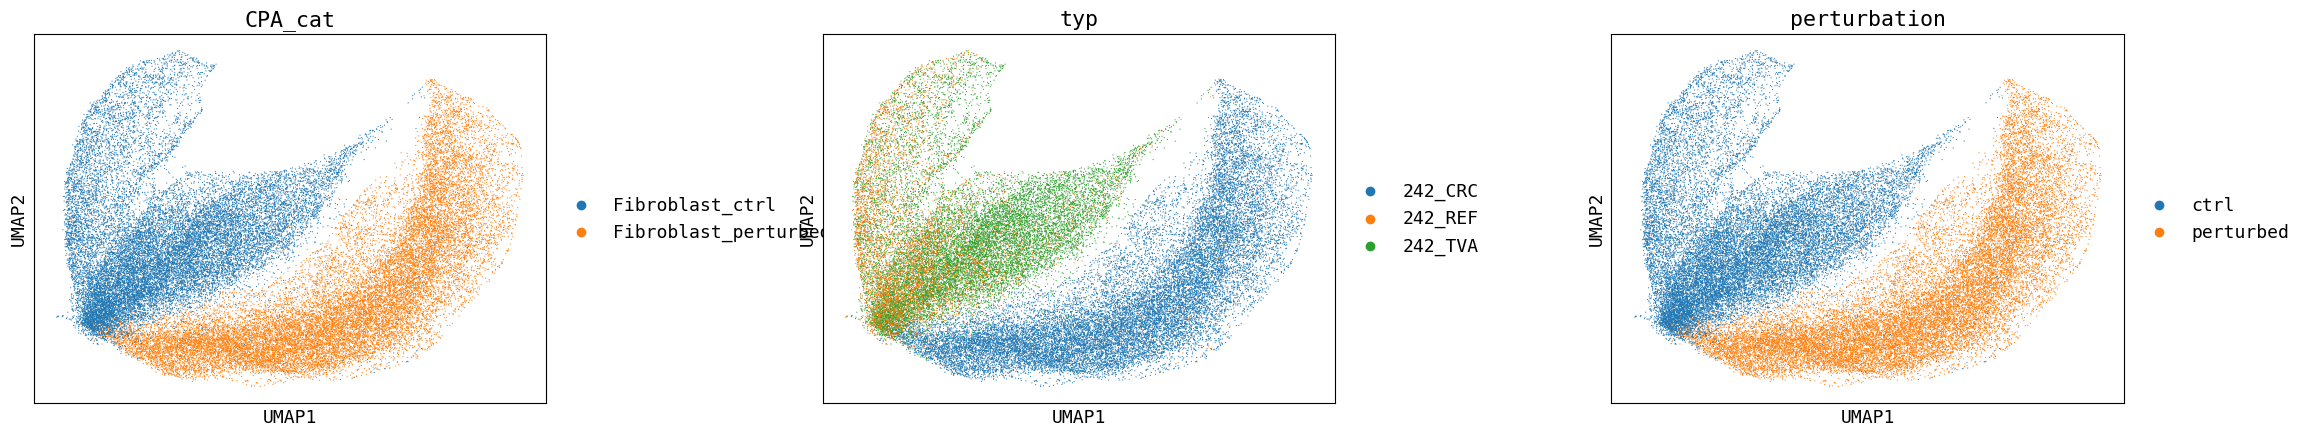

In [93]:
sc.pl.umap(adata_fib, color=['CPA_cat', domains_key, 'perturbation'], wspace=0.4)

In [100]:
adata.obs

,fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68_CK8_18,...,n_counts,is_holdout,data_split,dose,perturbation,CPA_cat,CPA_ctrl,_scvi_perturbation,_scvi_coarse_type,_scvi_CPA_cat
c_4_34_269,34,11860,1.07,4064,953,137,128,173,1392,80,...,672.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_290,34,9622,1.16,4108,1042,141,122,184,2968,296,...,592.0,False,train,1.0,perturbed,Myeloid_perturbed,0,1,4,9
c_4_34_296,34,15355,1.02,3981,1071,167,163,154,1444,106,...,1413.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_308,34,7943,1.29,4095,1111,142,110,188,2140,291,...,403.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
c_4_34_322,34,6797,0.71,4210,1155,90,127,2437,24804,58,...,329.0,True,ood,1.0,perturbed,Fibroblast_perturbed,0,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_4_221_1852,221,7678,1.81,3080,4218,134,74,26,1224,21,...,330.0,False,train,1.0,ctrl,Smooth_muscle_ctrl,1,0,6,12
c_4_221_1854,221,6639,2.03,481,4223,130,64,50,828,40,...,195.0,False,train,1.0,ctrl,Smooth_muscle_ctrl,1,0,6,12
c_4_221_1855,221,7568,2.63,1368,4223,168,64,45,900,65,...,547.0,False,valid,1.0,ctrl,Smooth_muscle_ctrl,1,0,6,12
c_4_221_1856,221,7569,2.88,1812,4223,184,64,11,784,22,...,248.0,False,train,1.0,ctrl,Smooth_muscle_ctrl,1,0,6,12


In [161]:
for cat in tqdm(adata_fib.obs['CPA_cat'].unique()):
    print(cat)

100%|██████████| 2/2 [00:00<00:00, 13210.41it/s]

Fibroblast_perturbed
Fibroblast_ctrl


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Endothelial', 'perturbed']


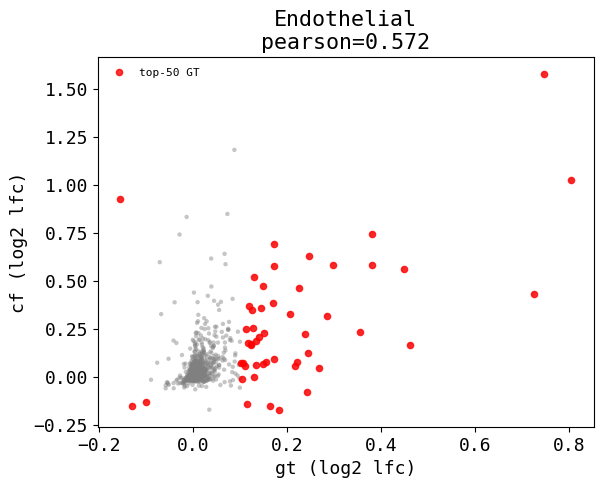

100%|██████████| 2/2 [00:00<00:00,  4.02it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Epithelial', 'perturbed']


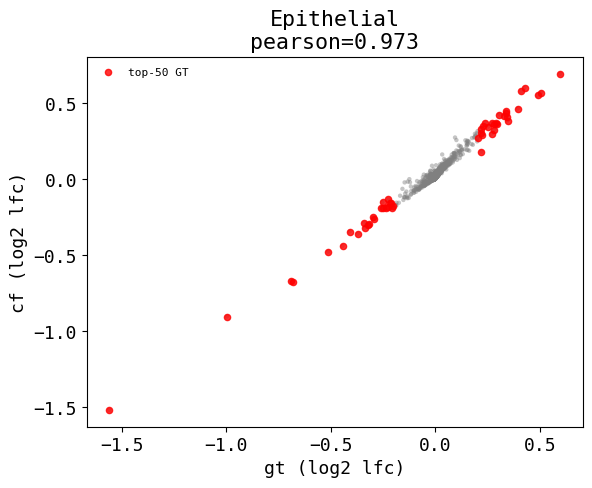

100%|██████████| 2/2 [01:34<00:00, 47.24s/it]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Fibroblast', 'perturbed']


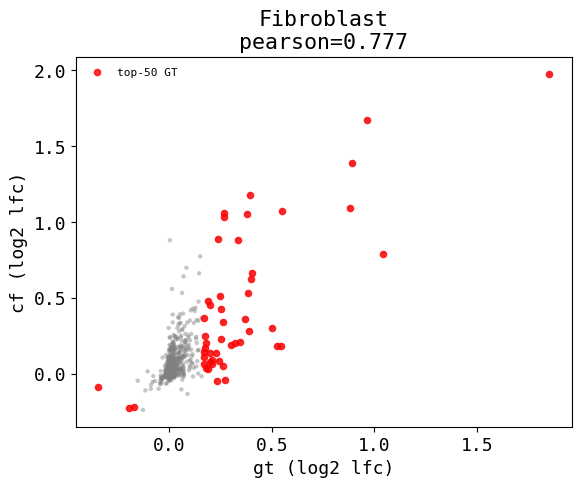

100%|██████████| 2/2 [00:06<00:00,  3.44s/it]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Mast', 'cell', 'perturbed']


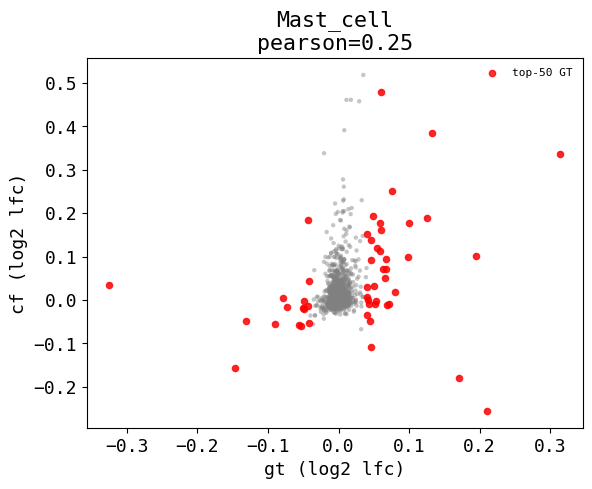

100%|██████████| 2/2 [00:00<00:00,  6.49it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Myeloid', 'perturbed']


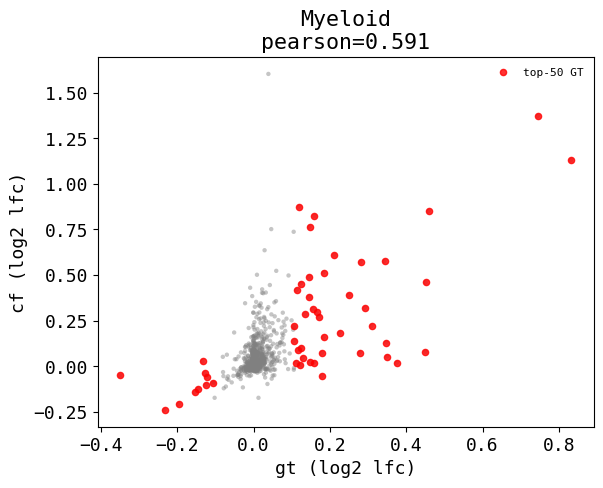

100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Plasma', 'cell', 'perturbed']


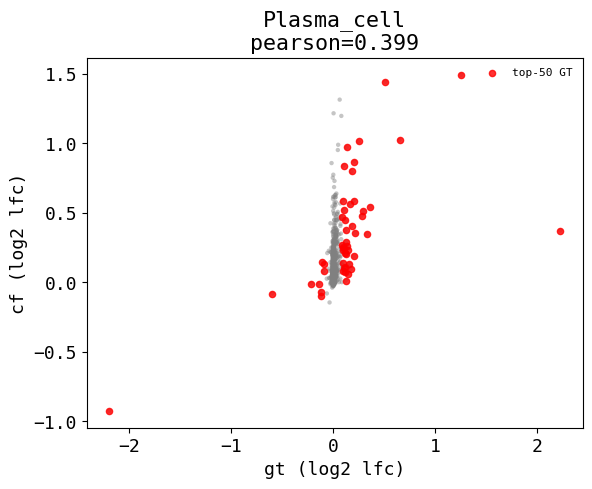

100%|██████████| 2/2 [00:01<00:00,  1.31it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['Smooth', 'muscle', 'perturbed']


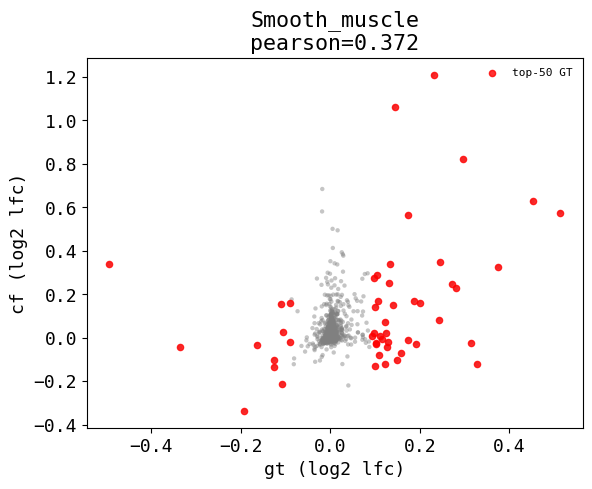

100%|██████████| 2/2 [00:00<00:00,  2.78it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


  0%|          | 0/2 [00:00<?, ?it/s]

['T', 'cell', 'perturbed']


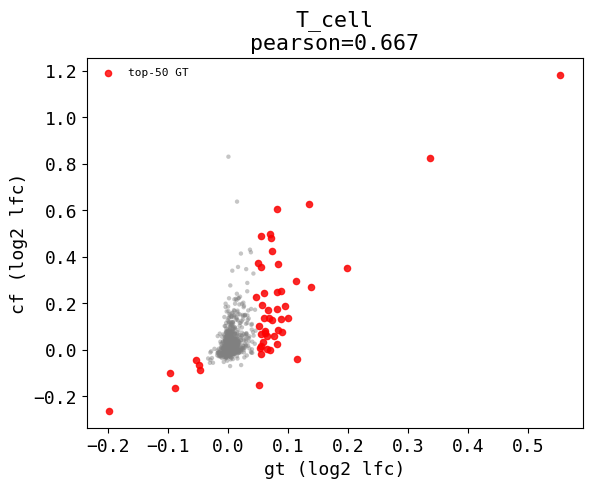

100%|██████████| 2/2 [00:01<00:00,  1.76it/s]


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

n_top_degs = [None] # None means all genes

for ct in adata.obs[labels_key].cat.categories:
    adata_sub = adata[adata.obs[labels_key]==ct].copy()
    model.predict(adata_sub, batch_size=batch_size)

    for cat in tqdm(adata_sub.obs['CPA_cat'].unique()):
        if 'ctrl' not in cat:
            cov, condition = "_".join(cat.split("_")[:-1]), cat.split("_")[-1]
            cat_adata = adata_sub[adata_sub.obs['CPA_cat'] == cat].copy()
            ctrl_adata = adata_sub[adata_sub.obs['CPA_cat'] == f'{cov}_ctrl'].copy()

            deg_cat = f'{cat}'

            x_true = cat_adata.layers['counts'].todense()
            x_pred = cat_adata.obsm['CPA_pred']
            x_ctrl = ctrl_adata.layers['counts'].todense()

            x_true = np.log1p(x_true)
            x_pred = np.log1p(x_pred)
            x_ctrl = np.log1p(x_ctrl)

            for n_top_deg in n_top_degs:
                degs = np.arange(adata.n_vars)
                n_top_deg = 'all'

                x_true_deg = np.array(x_true[:, degs])
                x_pred_deg = np.array(x_pred[:, degs])
                x_ctrl_deg = np.array(x_ctrl[:, degs])

                gt = x_true_deg.mean(0) - x_ctrl_deg.mean(0)
                cf = x_pred_deg.mean(0) - x_ctrl_deg.mean(0)

                from scipy.stats import pearsonr, spearmanr
                pear, _ = pearsonr(gt, cf)
                spearman, _ = spearmanr(gt, cf)

                k = 50
                results = []

                results.append(
                    {"celltype": ct, "pearson": pear, "spearman": spearman}
                )
                plt.scatter(gt, cf, s=10, alpha=0.45, color="gray", edgecolors="none")
                # highlight top-k GT genes
                top_idx = np.argsort(-np.abs(gt))[:k]
                plt.scatter(
                    gt[top_idx],
                    cf[top_idx],
                    s=20,
                    color="red",
                    alpha=0.8,
                    label=f"top-{k} GT",
                )
                # metrics for title
                res = next((r for r in results if r["celltype"] == ct), None)
                pear = res["pearson"] if res is not None else np.nan
                plt.title(
                    f"{ct}\npearson={np.round(pear, 3) if not pd.isna(pear) else 'nan'}"
                )
                plt.xlabel("gt (log2 lfc)")
                plt.ylabel("cf (log2 lfc)")
                plt.legend(frameon=False, fontsize=8)
                plt.show()


Celltypes:   0%|          | 0/8 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Celltypes:  12%|█▎        | 1/8 [00:00<00:06,  1.00it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Celltypes:  25%|██▌       | 2/8 [01:48<06:20, 63.50s/it]

...

Celltypes:  75%|███████▌  | 6/8 [01:58<00:21, 10.79s/it]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Celltypes:  88%|████████▊ | 7/8 [01:59<00:07,  7.69s/it]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Celltypes: 100%|██████████| 8/8 [02:01<00:00, 15.18s/it]


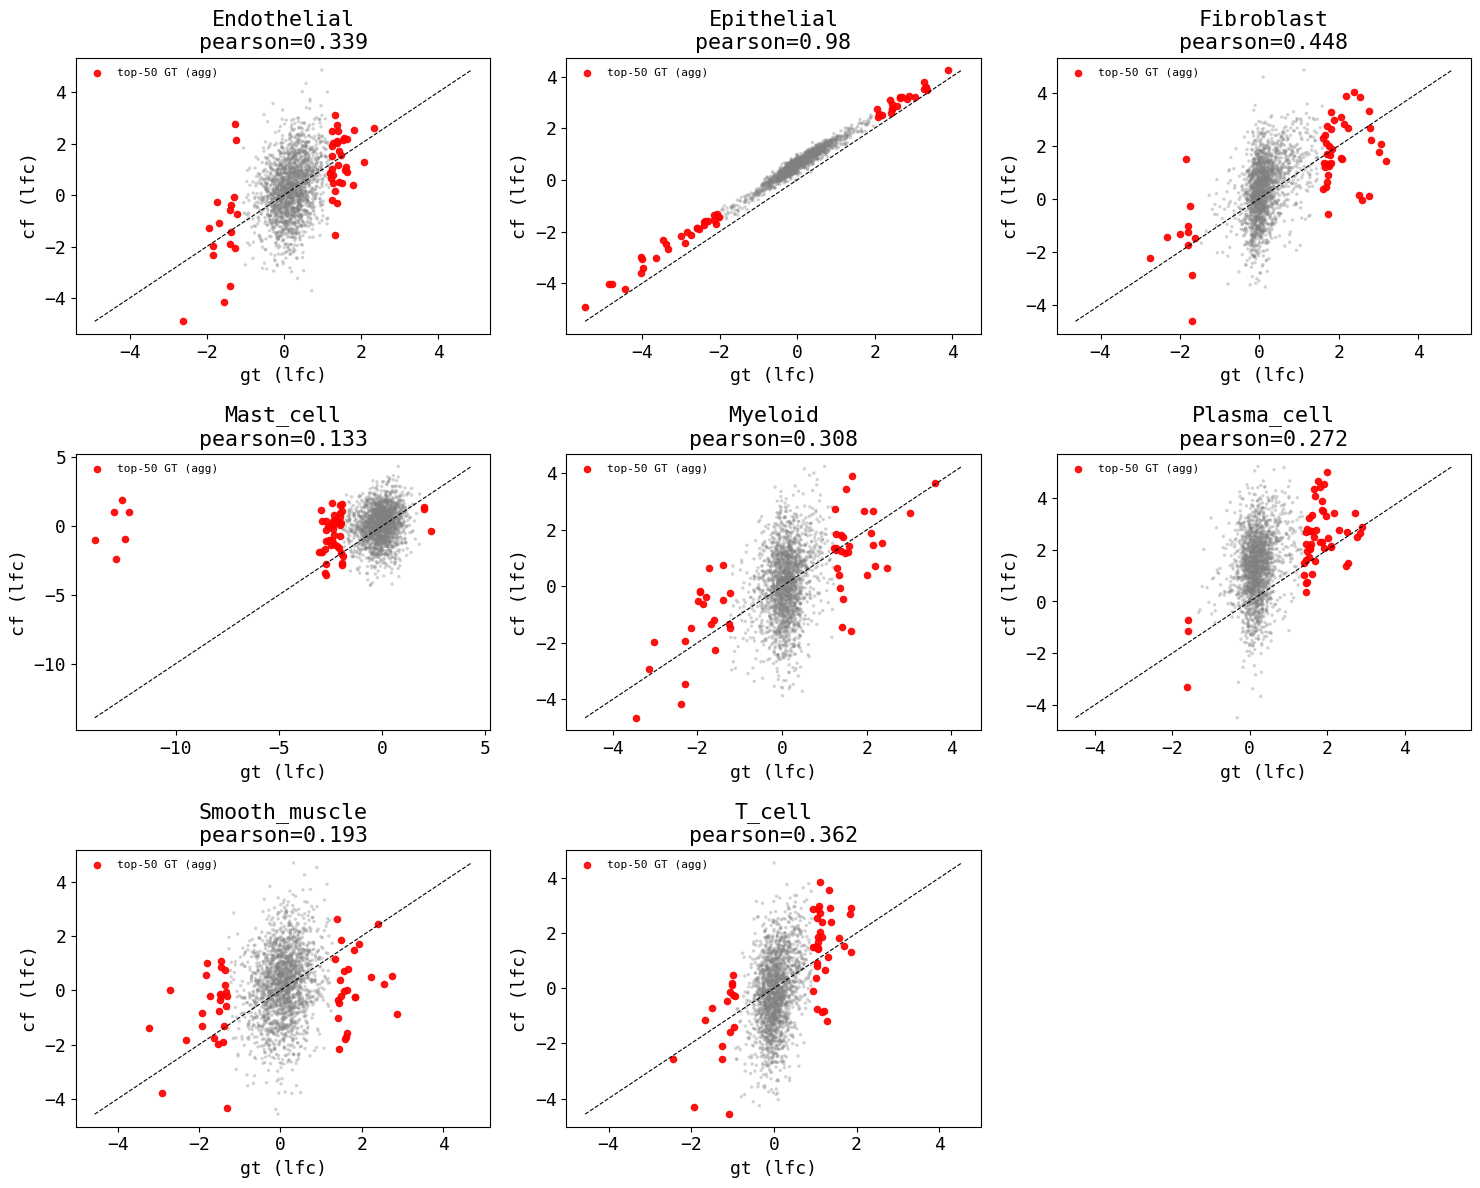

In [ ]:
# ...existing code...
import math
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

n_top_degs = [None]  # None means all genes
k = 50  # top-k for highlighting
results = []  # per-(celltype, CPA_cat) results
vectors = {}
eps = 1e-6

out_dir = "../results"
os.makedirs(out_dir, exist_ok=True)

# Prepare list of celltypes
celltypes = adata.obs[labels_key].cat.categories.tolist()
n_ct = len(celltypes)

# Layout: adjust ncols as you prefer
ncols = 3
nrows = math.ceil(n_ct / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, ct in enumerate(tqdm(celltypes, desc="Celltypes")):
    ax = axes_flat[i]
    adata_sub = adata[adata.obs[labels_key] == ct].copy()
    model.predict(adata_sub, batch_size=batch_size)

    cats = [c for c in adata_sub.obs['CPA_cat'].unique() if 'ctrl' not in c]
    if len(cats) == 0:
        ax.axis("off")
        continue

    # For this consolidated view: aggregate across categories by plotting all (gt,cf) points together
    all_gt = []
    all_cf = []
    pear_list = []
    spearman_list = []

    for cat in cats:
        cov = "_".join(cat.split("_")[:-1])
        cat_adata = adata_sub[adata_sub.obs['CPA_cat'] == cat].copy()
        ctrl_adata = adata_sub[adata_sub.obs['CPA_cat'] == f'{cov}_ctrl'].copy()

        # safety: skip if ctrl/category missing
        if cat_adata.n_obs == 0 or ctrl_adata.n_obs == 0:
            continue

        x_true = np.array(cat_adata.layers['counts'].todense())
        x_pred = cat_adata.obsm['CPA_pred']
        x_ctrl = np.array(ctrl_adata.layers['counts'].todense())

        x_true = np.log1p(x_true)
        x_pred = np.log1p(x_pred)
        x_ctrl = np.log1p(x_ctrl)
        
        mean_target = x_true.mean(axis=0)
        mean_pred = x_pred.mean(axis=0)
        mean_control = x_ctrl.mean(axis=0)
        
        from counterfactual_analysis import safe_log2_fold_change
        gt = safe_log2_fold_change(mean_target, mean_control)
        cf = safe_log2_fold_change(mean_pred, mean_control)

        # store for aggregated plotting and later inspection
        all_gt.append(gt)
        all_cf.append(cf)
        vectors.setdefault(ct, []).append({"cat": cat, "gt": gt, "cf": cf, "genes": np.asarray(adata.var_names)})

        # compute robust correlations per category
        try:
            valid = np.isfinite(gt) & np.isfinite(cf)
            if valid.sum() < 2 or (np.nanstd(gt[valid]) == 0) or (np.nanstd(cf[valid]) == 0):
                pear = np.nan
                spearman = np.nan
            else:
                from scipy.stats import pearsonr, spearmanr
                pear, _ = pearsonr(gt[valid], cf[valid])
                spearman, _ = spearmanr(gt[valid], cf[valid])
        except Exception:
            pear = np.nan
            spearman = np.nan

        pear_list.append(pear)
        spearman_list.append(spearman)
        results.append({"celltype": ct, "category": cat, "pearson": pear, "spearman": spearman})

    if len(all_gt) == 0:
        ax.axis("off")
        continue

    # concatenate (gt,cf) across categories for this celltype
    all_gt = np.concatenate(all_gt, axis=0)
    all_cf = np.concatenate(all_cf, axis=0)

    # scatter
    ax.scatter(all_gt, all_cf, s=6, alpha=0.35, color="gray", edgecolors="none")
    # highlight top-k genes by mean absolute GT across categories
    mean_gt = np.nanmean(np.vstack([g for g in vectors[ct]], dtype=object), axis=0) if False else None  # placeholder - keep per-category top-k instead
    top_idx = np.argsort(-np.abs(all_gt))[:k]
    ax.scatter(all_gt[top_idx], all_cf[top_idx], s=20, color="red", alpha=0.9, label=f"top-{k} GT (agg)")

    mn = np.nanmin([np.nanmin(all_gt), np.nanmin(all_cf)])
    mx = np.nanmax([np.nanmax(all_gt), np.nanmax(all_cf)])
    if np.isfinite(mn) and np.isfinite(mx):
        ax.plot([mn, mx], [mn, mx], color="black", linewidth=0.8, linestyle="--")

    # display mean correlation across categories in title
    mean_pear = np.nanmean(pear_list) if len(pear_list) > 0 else np.nan
    ax.set_title(f"{ct}\npearson={np.round(mean_pear,3) if not pd.isna(mean_pear) else 'nan'}")
    ax.set_xlabel("gt (lfc)")
    ax.set_ylabel("cf (lfc)")
    ax.legend(frameon=False, fontsize=8)

# turn off unused axes
for j in range(n_ct, nrows * ncols):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()
# ...existing code...

In [200]:
# assemble results dataframe and a per-celltype summary (mean across categories)
results_df = pd.DataFrame(results)
summary_df = results_df.groupby("celltype")[["pearson", "spearman"]].mean().reset_index()

# save for later use
summary_df.to_csv(os.path.join(out_dir, "cpa_by_celltype_correlations.csv"), index=False)

# expose variables in notebook
display(summary_df)

,celltype,pearson,spearman
0,Endothelial,0.339119,0.314949
1,Epithelial,0.979620,0.946363
2,Fibroblast,0.448488,0.435961
3,Mast_cell,0.132770,0.176073
4,Myeloid,0.307666,0.240928
5,Plasma_cell,0.272427,0.235331
6,Smooth_muscle,0.192796,0.188488
7,T_cell,0.362150,0.315166


In [55]:
from counterfactual_analysis import get_counterfactual_preds

In [56]:
results_adatas = {k: {} for k in ['cpa']}

In [57]:
results_adatas[model_class] = get_counterfactual_preds(model, adata, labels_key, model_class)

  0%|          | 0/1 [00:00<?, ?it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 684/684 [00:16<00:00, 41.17it/s]


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 684/684 [00:15<00:00, 44.18it/s]

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        



100%|██████████| 1/1 [01:21<00:00, 81.29s/it]


In [58]:
results_adatas

{'cpa': {'Fibroblast': AnnData object with n_obs × n_vars = 66304 × 2000
      obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0

100%|██████████| 1/1 [00:00<00:00,  1.62it/s]


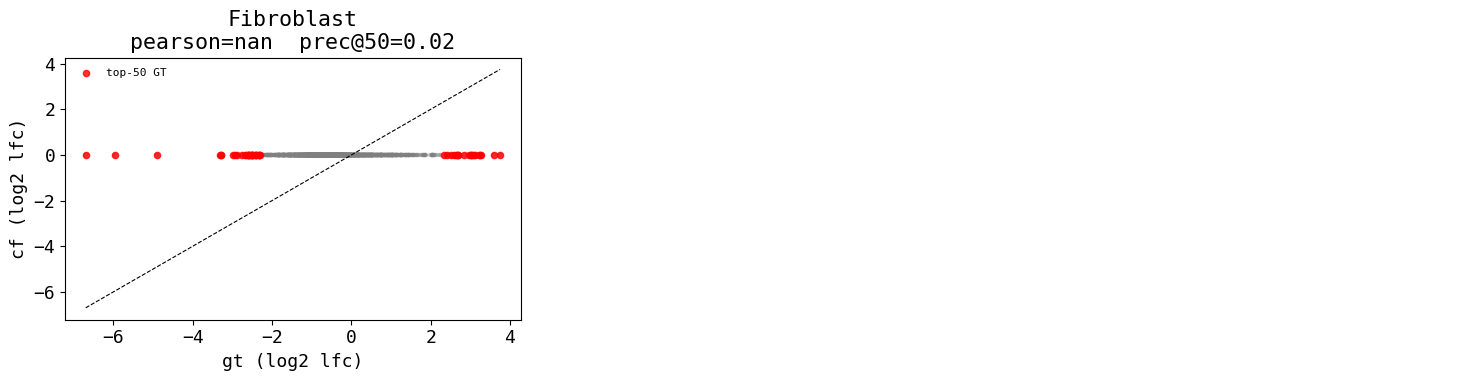

In [59]:
# Differential Expression
from counterfactual_analysis import get_de_correlations
k = 50
# cpa
results_cpa, vectors = get_de_correlations(results_adatas['cpa'], k=k, plot=True, use_recon=True)
metrics_cpa = pd.DataFrame(results_cpa).set_index('celltype').sort_values(by=f'prec@{k}', ascending=False)

100%|██████████| 7/7 [00:02<00:00,  2.92it/s]


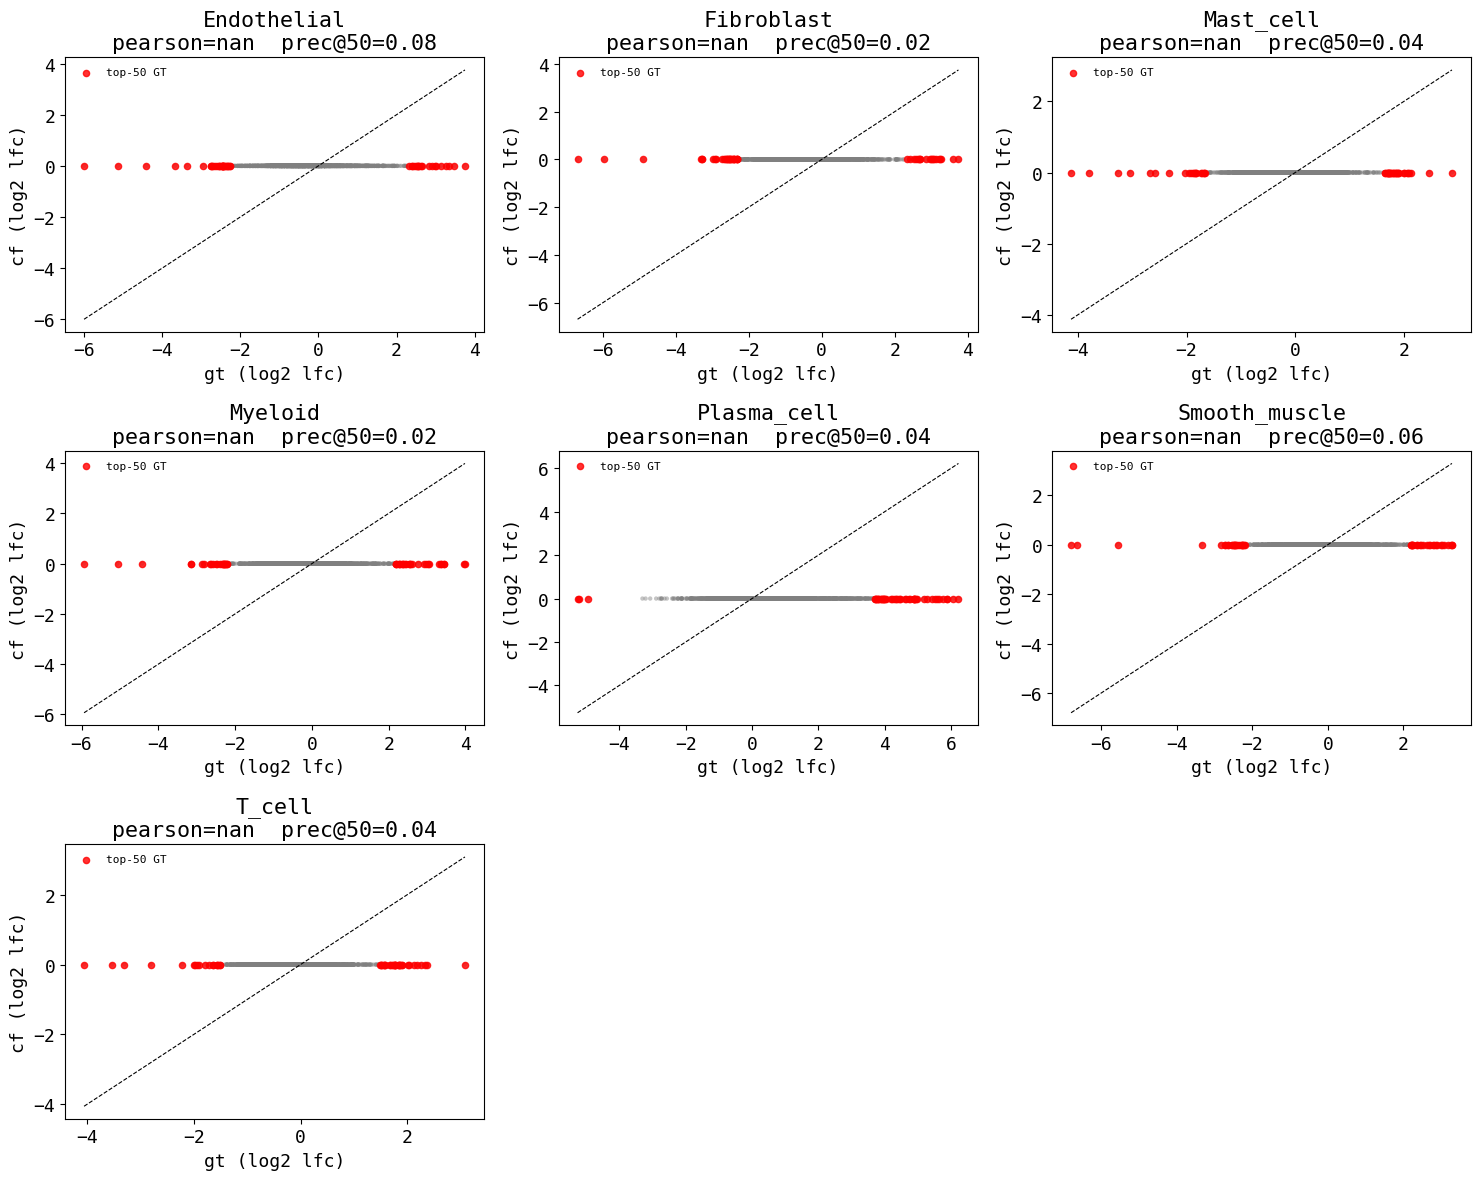

In [ ]:
# non covariates
from counterfactual_analysis import get_de_correlations
k = 50
# cpa
results_cpa, vectors = get_de_correlations(results_adatas['cpa'], k=k, plot=True, use_recon=True)
metrics_cpa = pd.DataFrame(results_cpa).set_index('celltype').sort_values(by=f'prec@{k}', ascending=False)

In [27]:
results = []
vectors = {}
use_recon = True

for ct, adata in tqdm(results_adatas['cpa'].items()):
    groups = adata.obs["group"].values
    var_names = np.asarray(adata.var_names)

    # get counts as dense array
    counts = adata.layers["counts"]  # shape: (n_cells, n_genes)

    # get ground truth control, target either from raw counts or reconstructed counts
    if use_recon:
        X_all = adata.obsm.get("recon_x")
    else:
        # normalize counts so each row sums to 1
        X_all = counts / (counts.sum(axis=1, keepdims=True) + 1e-8)
    # model-normalized counterfactuals (may be None)
    recon_all = adata.obsm.get("recon_x")

    # masks
    mask_control = groups == "control"
    mask_target = groups == "target"
    mask_cf = groups == "counterfactual"

    if mask_control.sum() == 0:
        # can't compute without real control baseline
        continue
    if mask_target.sum() == 0 and mask_cf.sum() == 0:
        # nothing to compare
        continue

    # compute group means (ensure arrays)
    mean_control = (
        X_all[mask_control].mean(axis=0)
        if mask_control.sum() > 0
        else np.zeros(X_all.shape[1])
    )
    mean_target = (
        X_all[mask_target].mean(axis=0)
        if mask_target.sum() > 0
        else np.zeros(X_all.shape[1])
    )
    mean_cf = recon_all[mask_cf].mean(axis=0)
    print(mean_control)
    print(mean_target)
    print(mean_cf)

    # compute gt and cf: observed perturbed (target) minus real control, and counterfactual minus real control
    from counterfactual_analysis import safe_log2_fold_change
    diff_method = safe_log2_fold_change
    eps = 1e-6

    try:
        gt_vec = diff_method(mean_target, mean_control, eps=eps)
        cf_vec = diff_method(mean_cf, mean_control, eps=eps)
    except Exception:
        # numeric issues: skip
        continue

    vectors[ct] = {"gt": gt_vec, "cf": cf_vec, "genes": var_names}

    # compute Pearson and Spearman on finite entries
    valid = np.isfinite(gt_vec) & np.isfinite(cf_vec)
    if (
        valid.sum() < 2
        or (np.nanstd(gt_vec[valid]) == 0)
        or (np.nanstd(cf_vec[valid]) == 0)
    ):
        pear = np.nan
        spearman = np.nan
    else:
        from scipy.stats import pearsonr, spearmanr
        pear, _ = pearsonr(gt_vec[valid], cf_vec[valid])
        spearman, _ = spearmanr(gt_vec[valid], cf_vec[valid])

 29%|██▊       | 2/7 [00:00<00:00, 14.49it/s]

[0.00825969 0.00012676 0.00018232 ... 0.00013848 0.00017587 0.00025561]
[2.7123939e-03 6.4890948e-05 8.1085524e-04 ... 3.2755161e-05 2.4079975e-04
 1.2982063e-04]
[0.00825969 0.00012676 0.00018232 ... 0.00013848 0.00017587 0.00025561]
[0.007098   0.00014989 0.00033745 ... 0.00015662 0.00023533 0.00025977]
[1.1661173e-03 3.8786766e-05 1.0096561e-03 ... 4.8874266e-05 4.5648406e-04
 1.3468867e-04]
[0.007098   0.00014989 0.00033745 ... 0.00015662 0.00023533 0.00025977]
[0.00173243 0.0001532  0.00045397 ... 0.00026075 0.00043022 0.00025774]
[1.0470432e-03 7.4564960e-05 1.0925923e-03 ... 4.9266800e-05 5.1485782e-04
 2.9635461e-04]
[0.00173243 0.0001532  0.00045397 ... 0.00026075 0.00043022 0.00025774]


 57%|█████▋    | 4/7 [00:00<00:00, 15.67it/s]

[0.0039711  0.00012203 0.00071782 ... 0.00014716 0.00021527 0.000157  ]
[8.1710820e-04 3.3506712e-05 4.7339960e-03 ... 6.8166308e-05 2.1018038e-04
 1.1641435e-04]
[0.0039711  0.00012203 0.00071782 ... 0.00014716 0.00021527 0.000157  ]


100%|██████████| 7/7 [00:00<00:00, 12.49it/s]

[1.5196683e-03 5.0472270e-05 1.5577939e-04 ... 9.4871320e-05 1.0610185e-04
 1.2234399e-04]
[8.3954178e-04 6.7732071e-05 1.2241706e-03 ... 2.9439387e-05 4.8308159e-04
 2.3487919e-04]
[1.5196683e-03 5.0472270e-05 1.5577939e-04 ... 9.4871320e-05 1.0610185e-04
 1.2234399e-04]
[0.0080966  0.0001109  0.00028656 ... 0.00012142 0.00019913 0.0002094 ]
[1.3864187e-03 8.6022454e-05 1.3512442e-03 ... 2.7187558e-05 2.3057207e-04
 2.1957023e-04]
[0.0080966  0.0001109  0.00028656 ... 0.00012142 0.00019913 0.0002094 ]
[0.00208946 0.00019655 0.00032438 ... 0.00032667 0.000382   0.00031958]
[4.0840791e-04 3.5316887e-05 7.7670976e-04 ... 1.0191757e-04 4.7332802e-04
 1.6018689e-04]
[0.00208946 0.00019655 0.00032438 ... 0.00032667 0.000382   0.00031958]


In [28]:
control = results_adatas['cpa']['Endothelial'][results_adatas['cpa']['Endothelial'].obs['group']=='control']

In [29]:
cf = results_adatas['cpa']['Endothelial'][results_adatas['cpa']['Endothelial'].obs['group']=='counterfactual']

In [30]:
control.obs['perturbation'].value_counts()

perturbation
ctrl    5864
Name: count, dtype: int64

In [31]:
cf.obs['perturbation'].value_counts()

perturbation
perturbed    5864
Name: count, dtype: int64

In [32]:
control.obsm["recon_x"]

ArrayView([[1.0912168e-02, 1.5537854e-04, 1.1161981e-04, ...,
            1.6171287e-04, 4.2405460e-05, 3.1783903e-04],
           [6.3947751e-03, 8.4354309e-05, 9.8748296e-04, ...,
            2.5454487e-04, 1.2110187e-04, 1.4385872e-04],
           [3.4089312e-03, 2.1298580e-04, 2.6752019e-05, ...,
            4.2188145e-05, 2.4093680e-04, 2.5406227e-05],
           ...,
           [7.4555440e-04, 8.5142739e-05, 2.8780819e-04, ...,
            5.7548378e-04, 1.1367510e-04, 2.8178183e-05],
           [1.4451552e-03, 6.8372909e-05, 7.9512305e-05, ...,
            2.1755365e-04, 1.6502025e-05, 3.3053965e-04],
           [4.8852083e-03, 2.7909785e-04, 6.5984495e-05, ...,
            1.7880300e-05, 2.7352828e-05, 2.9645136e-04]], dtype=float32)

In [33]:
cf.obsm["recon_x"]

ArrayView([[1.0912168e-02, 1.5537854e-04, 1.1161981e-04, ...,
            1.6171287e-04, 4.2405460e-05, 3.1783903e-04],
           [6.3947751e-03, 8.4354309e-05, 9.8748296e-04, ...,
            2.5454487e-04, 1.2110187e-04, 1.4385872e-04],
           [3.4089312e-03, 2.1298580e-04, 2.6752019e-05, ...,
            4.2188145e-05, 2.4093680e-04, 2.5406227e-05],
           ...,
           [7.4555440e-04, 8.5142739e-05, 2.8780819e-04, ...,
            5.7548378e-04, 1.1367510e-04, 2.8178183e-05],
           [1.4451552e-03, 6.8372909e-05, 7.9512305e-05, ...,
            2.1755365e-04, 1.6502025e-05, 3.3053965e-04],
           [4.8852083e-03, 2.7909785e-04, 6.5984495e-05, ...,
            1.7880300e-05, 2.7352828e-05, 2.9645136e-04]], dtype=float32)